# Cyclophilin D Binding-Mode Family Analysis

In [1]:
import pandas as pd
from Bio import AlignIO
from Bio.Align import substitution_matrices
from itertools import combinations
import seaborn as snsa
import matplotlib.pyplot as plt

blosum62 = substitution_matrices.load("BLOSUM62")

## Helper functions

In [2]:
def blosum_pair_score(a, b):
    """Look up BLOSUM62 score for a residue pair, handling gaps."""
    if a == "-" or b == "-":
        return None
    try:
        return blosum62[a, b]
    except KeyError:
        return blosum62[b, a]


def column_conservation(column_residues):
    """
    Compute BLOSUM62-weighted conservation for one alignment column.
    Returns (avg_pairwise_score, pct_identity, n_sequences_with_residue).
    """
    residues = [r for r in column_residues if r != "-"]
    n = len(residues)
    if n < 2:
        return None, None, n

    pair_scores = [blosum_pair_score(a, b) for a, b in combinations(residues, 2)]
    avg_score = sum(pair_scores) / len(pair_scores)

    most_common = max(set(residues), key=residues.count)
    pct_identity = residues.count(most_common) / n * 100

    return avg_score, pct_identity, n


def ref_pos_to_alignment_col(ref_aligned_seq, target_pos_1indexed):
    """
    Map a 1-indexed ungapped residue position in the reference sequence
    to its 0-indexed column in the alignment.
    """
    ungapped_count = 0
    for col_idx, char in enumerate(ref_aligned_seq):
        if char != "-":
            ungapped_count += 1
            if ungapped_count == target_pos_1indexed:
                return col_idx
    return None

# Data Analysis

## Residue Conservation Analysis (BLOSUM62)

In [3]:
CSV_PATH = "binding_site_conservation/residues.csv"  # NAME,UID,TYPE,COLOR
ALN_PATH = "binding_site_conservation/human_cyclophilins_filtered_aligned_MAFFT.fasta"  # aligned FASTA (gapped)
REF_ID_SUBSTRING = "PPIF_HUMAN"  # substring identifying reference seq in alignment

residues_df = pd.read_csv(CSV_PATH)
residues_df

,NAME,UID,TYPE,COLOR
0,GLN,105,Acc Side,Red
1,ASN,144,Don Back,Red
2,ASN,144,Acc Back,Red
3,ARG,97,Acc Side,Red
4,THR,149,Don Back,Yellow
5,ARG,124,Acc Side,Yellow
6,PRO,126,Arn Con,Green
7,LYS,73,Acc Side,Green
8,TYR,121,Arn Con,Green
9,TRP,163,Arn Con,Purple


### If sequences were flagged as mismatched above

Common fixes:
- **Different gap character**: if your exporter used `.` instead of `-`, uncomment the line below.
- **Drop bad record(s)**: exclude a specific sequence by ID if it wasn't actually aligned (e.g. re-export from Jalview/MOE and retry instead).

```python
# records = [SeqRecord(Seq(str(r.seq).replace(".", "-")), id=r.id, description=r.description) for r in records]
# records = [r for r in records if r.id not in {"bad_id_1", "bad_id_2"}]
```
Re-run the cell above after fixing.

In [4]:
from Bio import SeqIO

records = list(SeqIO.parse(ALN_PATH, "fasta"))
lengths = {r.id: len(r.seq) for r in records}
length_counts = pd.Series(list(lengths.values())).value_counts()

print(f"Loaded {len(records)} sequences")
print("Sequence length distribution:")
print(length_counts)

# Diagnostic: flag any records whose length doesn't match the majority length
majority_length = length_counts.idxmax()
mismatched = {rid: L for rid, L in lengths.items() if L != majority_length}

if mismatched:
    print(
        f"\n{len(mismatched)} sequence(s) do NOT match the majority length ({majority_length}):"
    )
    for rid, L in mismatched.items():
        print(f"  {rid}: length {L}")
    raise ValueError(
        "Alignment is not uniform length. Common causes: a sequence was saved "
        "unaligned, gap character mismatch ('.' vs '-'), or trailing whitespace. "
        "Re-check/re-export the offending record(s) above, or filter them out below."
    )

aln = records
print(f"\nAll {len(aln)} sequences are aligned length {majority_length} — OK")

ref_record = next((r for r in aln if REF_ID_SUBSTRING in r.id), None)
if ref_record is None:
    raise ValueError(
        f"Reference containing '{REF_ID_SUBSTRING}' not found in alignment."
    )
ref_seq = str(ref_record.seq)
print(f"Reference: {ref_record.id}")

Loaded 18 sequences
Sequence length distribution:
4585    18
Name: count, dtype: int64

All 18 sequences are aligned length 4585 — OK
Reference: sp|P30405|PPIF_HUMAN/1-207


## Compute conservation per residue

In [5]:
results = []
for _, row in residues_df.iterrows():
    uid_raw = str(row["UID"])
    if "-" in uid_raw:  # skip ranges like "1-2"; handle manually if needed
        print(f"Skipping range UID: {row['NAME']} {uid_raw} (handle manually)")
        continue

    uid = int(uid_raw)
    col = ref_pos_to_alignment_col(ref_seq, uid)
    if col is None:
        print(f"Could not map {row['NAME']}{uid} to alignment — check numbering.")
        continue

    column_residues = [str(r.seq)[col] for r in aln]
    avg_score, pct_id, n_present = column_conservation(column_residues)

    results.append(
        {
            "NAME": row["NAME"],
            "UID": uid,
            "TYPE": row["TYPE"],
            "COLOR": row["COLOR"],
            "alignment_col": col,
            "n_sequences_present": n_present,
            "pct_identity": round(pct_id, 1) if pct_id is not None else None,
            "avg_blosum62_score": round(avg_score, 2)
            if avg_score is not None
            else None,
        }
    )

out_df = (
    pd.DataFrame(results)
    .sort_values("avg_blosum62_score")
    .drop_duplicates(subset="UID")
)
out_df

,NAME,UID,TYPE,COLOR,alignment_col,n_sequences_present,pct_identity,avg_blosum62_score
5,ARG,124,Acc Side,Yellow,3172,18,27.8,-0.24
13,HIS,173,Arn Con,Orange,3230,18,33.3,0.74
11,LYS,190,Acc Side,Purple,3248,18,38.9,0.82
6,PRO,126,Arn Con,Green,3174,18,44.4,0.90
19,ASP,202,Don Side,Teal,3262,17,47.1,1.53
14,LYS,67,Acc Side,Orange,3102,18,55.6,1.84
22,LYS,91,Acc Side,Teal,3139,18,66.7,2.33
15,LEU,132,Arn Con,Navy,3188,18,72.2,2.49
9,TRP,163,Arn Con,Purple,3220,18,50.0,2.99
4,THR,149,Don Back,Yellow,3205,18,77.8,3.00


## Save Conservation Results


In [6]:
out_df.to_csv("processed_data/conservation_results.xlsx", index=False)
print("Saved to processed_data/conservation_results.xlsx")

Saved to processed_data/conservation_results.xlsx


NameError: name 'sns' is not defined

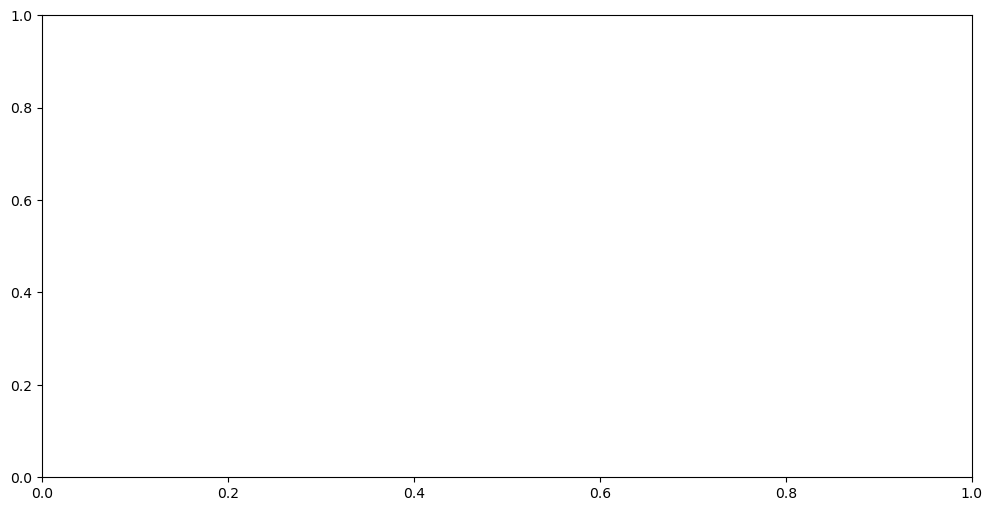

In [7]:
SITE_COLOR_MAP = {
    "Red": "#B22222",
    "Yellow": "#DAA520",
    "Green": "#2E7D32",
    "Purple": "#6A1B9A",
    "Orange": "#E65100",
    "Navy": "#1A3E6F",
    "Teal": "#008080",
}

SITE_ORDER = ["Red", "Purple", "Yellow", "Green", "Teal", "Navy", "Orange"]

METRICS = {
    "blosum": {
        "col": "avg_blosum62_score",
        "ylabel": "Avg pairwise BLOSUM62 score",
        "title": "Residue conservation (BLOSUM62-weighted) by site",
        "ylim": None,
    },
    "identity": {
        "col": "pct_identity",
        "ylabel": "% identity",
        "title": "Residue conservation (% identity) by site",
        "ylim": (0, 100),
    },
}


def plot_conservation_by_site(df, metric="blosum", figsize=(12, 6)):
    """metric: 'blosum' or 'identity'"""
    if metric not in METRICS:
        raise ValueError(f"metric must be one of {list(METRICS)}")
    m = METRICS[metric]
    score_col = m["col"]

    plot_df = df.copy()
    plot_df["residue_label"] = (
        plot_df["NAME"].str.title() + " " + plot_df["UID"].astype(str)
    )
    plot_df["site_rank"] = plot_df["COLOR"].apply(
        lambda c: SITE_ORDER.index(c) if c in SITE_ORDER else len(SITE_ORDER)
    )
    plot_df = plot_df.sort_values(["site_rank", score_col], ascending=[True, False])

    palette = {c: SITE_COLOR_MAP.get(c, "#888888") for c in plot_df["COLOR"].unique()}

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=plot_df,
        x="residue_label",
        y=score_col,
        hue="COLOR",
        order=plot_df["residue_label"],
        palette=palette,
        dodge=False,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("")
    ax.set_ylabel(m["ylabel"])
    ax.set_title(m["title"])
    if m["ylim"]:
        ax.set_ylim(*m["ylim"])
    plt.xticks(rotation=60, ha="right")
    ax.legend(title="Site", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    return fig, ax


fig, ax = plot_conservation_by_site(out_df, metric="blosum")
fig.savefig("processed_data/conservation_blosum62_by_site.png", dpi=300)
plt.show()


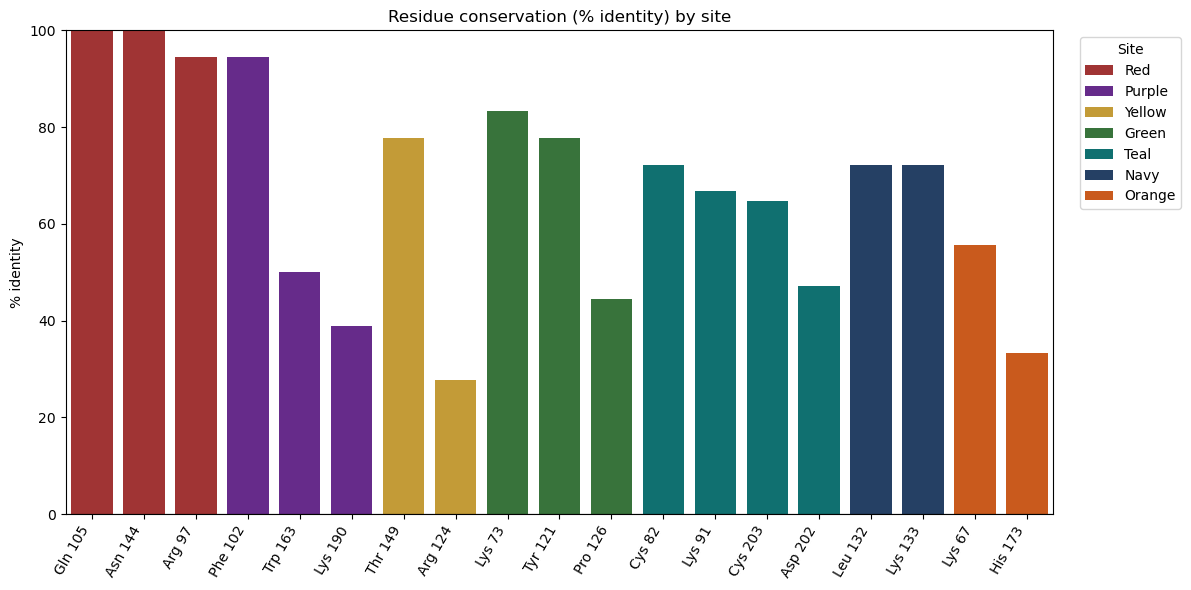

In [ ]:
fig, ax = plot_conservation_by_site(out_df, metric="identity")
fig.savefig("processed_data/conservation_identity_by_site.png", dpi=300)
plt.show()

In [8]:
for x in out_df.groupby("COLOR"):
    print(x[1]["COLOR"].iloc[0], x[1]["avg_blosum62_score"].mean())

Green 3.2900000000000005
Navy 2.75
Orange 1.29
Purple 2.936666666666667
Red 5.146666666666667
Teal 2.9025
Yellow 1.38


In [9]:
for x in out_df.groupby("COLOR"):
    print(x[1]["COLOR"].iloc[0], x[1]["pct_identity"].mean())

Green 68.5
Navy 72.2
Orange 44.45
Purple 61.1
Red 98.13333333333333
Teal 62.675
Yellow 52.8
